# Subsidence Calculator (Notebook Only)

This notebook provides a complete Jupyter-only workflow for:
- entering all required inputs,
- calculating subsidence outputs

In [16]:
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output

from subsidence_calculator import create_report, format_report, point_in_polygon, distance_to_polygon_boundary, subsidence_at_point

## Inputs

Enter panel points in the text box as one point per line using:

`easting,northing`

Example:

`0,0`
`100,0`
`100,100`
`0,100`

In [17]:
panel_points_text = widgets.Textarea(
    value="0,0\n100,0\n100,100\n0,100",
    description="Panel points:",
    layout=widgets.Layout(width="420px", height="140px"),
    style={"description_width": "110px"},
)

thickness = widgets.FloatText(value=2.5, description="h (m):", style={"description_width": "110px"})
depth_of_cover = widgets.FloatText(value=300.0, description="H (m):", style={"description_width": "110px"})
extraction_ratio = widgets.Dropdown(
    options=[("Longwall (1.0)", 1.0), ("Board and Pillar (0.7)", 0.7), ("Custom 0.9", 0.9)],
    value=1.0,
    description="Extraction:",
    style={"description_width": "110px"},
)
subsidence_factor = widgets.FloatText(value=0.5, description="a:", style={"description_width": "110px"})
new_ratio = widgets.FloatText(value=1.4, description="W(new)/H:", style={"description_width": "110px"})
angle_of_draw = widgets.FloatText(value=35.0, description="alpha (deg):", style={"description_width": "110px"})
mesh_spacing = widgets.FloatText(value=25.0, description="Mesh (m):", style={"description_width": "110px"})

show_matplotlib = widgets.Checkbox(value=True, description="Also show matplotlib multi-panel plots")
calculate_btn = widgets.Button(description="Calculate", button_style="primary")

summary_out = widgets.Output()
plot_out = widgets.Output()

In [18]:
def parse_panel_points(raw_text):
    points = []
    for line in raw_text.strip().splitlines():
        line = line.strip()
        if not line:
            continue
        parts = [p.strip() for p in line.split(',')]
        if len(parts) != 2:
            raise ValueError(f"Invalid point format: '{line}'. Use easting,northing")
        easting = float(parts[0])
        northing = float(parts[1])
        points.append((easting, northing))

    if len(points) < 3:
        raise ValueError("At least 3 panel points are required.")

    if len(set(points)) < 3:
        raise ValueError("At least 3 unique panel points are required.")

    return points


def point_on_or_inside_polygon(easting, northing, polygon, tolerance=1e-9):
    if point_in_polygon(easting, northing, polygon):
        return True
    return distance_to_polygon_boundary(easting, northing, polygon) <= tolerance


def build_display_mesh(report):
    panel = [(p["easting"], p["northing"]) for p in report["inputs"]["panel_points"]]
    if not panel:
        return []

    mesh_spacing_value = float(report["inputs"]["mesh_spacing"])
    influence_distance = float(report["calculated"]["influence_distance"])
    max_subsidence = float(report["calculated"]["s_max"])

    west = min(point[0] for point in panel)
    east = max(point[0] for point in panel)
    south = min(point[1] for point in panel)
    north = max(point[1] for point in panel)

    mesh_points = []
    easting = west
    while easting <= east + 1e-9:
        northing = south
        while northing <= north + 1e-9:
            if point_on_or_inside_polygon(easting, northing, panel):
                value = subsidence_at_point(easting, northing, panel, max_subsidence, influence_distance)
                mesh_points.append({
                    "easting": round(easting, 2),
                    "northing": round(northing, 2),
                    "subsidence": round(value, 4),
                })
            northing += mesh_spacing_value
        easting += mesh_spacing_value

    return mesh_points


def build_plotly_map(report):
    mesh_points = build_display_mesh(report)
    if not mesh_points:
        return None

    panel = report["inputs"]["panel_points"]
    max_subsidence = max((p["subsidence"] for p in mesh_points), default=0.0)
    mesh_spacing_value = float(report["inputs"]["mesh_spacing"])
    min_radius = mesh_spacing_value * 0.18
    max_radius = mesh_spacing_value * 0.45

    figure = go.Figure()
    for point in mesh_points:
        subsidence = point["subsidence"]
        ratio = subsidence / max_subsidence if max_subsidence > 0 else 0.0
        radius = min_radius + (max_radius - min_radius) * ratio
        color_mm = subsidence * 1000.0
        figure.add_shape(
            type="circle",
            xref="x",
            yref="y",
            x0=point["easting"] - radius,
            y0=point["northing"] - radius,
            x1=point["easting"] + radius,
            y1=point["northing"] + radius,
            line={"color": "black", "width": 1.2},
            fillcolor="rgba(255, 165, 0, 0.20)",
        )
        figure.add_trace(
            go.Scatter(
                x=[point["easting"]],
                y=[point["northing"]],
                mode="markers",
                name="Mesh point",
                marker={
                    "size": 6,
                    "color": "black",
                },
                hovertemplate="E: %{x:.2f}<br>N: %{y:.2f}<br>S: " + f"{color_mm:.2f}" + " mm<extra></extra>",
                showlegend=False,
            )
        )

    if panel:
        px = [p["easting"] for p in panel] + [panel[0]["easting"]]
        py = [p["northing"] for p in panel] + [panel[0]["northing"]]
        figure.add_trace(
            go.Scatter(
                x=px,
                y=py,
                mode="lines",
                name="Panel boundary",
                line={"color": "navy", "width": 3},
                hoverinfo="skip",
            )
        )

    figure.update_layout(
        title="Notebook Subsidence Map - Circle Radius by Subsidence",
        xaxis_title="Easting (m)",
        yaxis_title="Northing (m)",
        yaxis={"scaleanchor": "x", "scaleratio": 1},
        template="plotly_white",
        height=650,
    )

    return figure


def plot_circle_mesh_view(report):
    mesh_points = build_display_mesh(report)
    if not mesh_points:
        print("No mesh points available for visualization.")
        return

    panel = report["inputs"]["panel_points"]
    mesh_spacing_value = float(report["inputs"]["mesh_spacing"])
    max_subsidence = max((p["subsidence"] for p in mesh_points), default=0.0)
    min_radius = mesh_spacing_value * 0.18
    max_radius = mesh_spacing_value * 0.45

    figure, ax = plt.subplots(figsize=(12, 10))
    for point in mesh_points:
        subsidence = point["subsidence"]
        ratio = subsidence / max_subsidence if max_subsidence > 0 else 0.0
        radius = min_radius + (max_radius - min_radius) * ratio
        circle = patches.Circle(
            (point["easting"], point["northing"]),
            radius=radius,
            facecolor="orange",
            edgecolor="black",
            linewidth=1.2,
            alpha=0.22,
        )
        ax.add_patch(circle)
        ax.plot(point["easting"], point["northing"], "ko", markersize=3.8)

    if panel:
        px = [p["easting"] for p in panel] + [panel[0]["easting"]]
        py = [p["northing"] for p in panel] + [panel[0]["northing"]]
        ax.plot(px, py, color="navy", linewidth=2.4, label="Panel boundary")
        ax.fill(px, py, color="navy", alpha=0.05)

    ax.set_title("Boundary Mesh Circles - Radius by Subsidence")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)
    if panel:
        ax.legend(loc="upper right")
    plt.show()


def on_calculate(_):
    with summary_out:
        clear_output(wait=True)
    with plot_out:
        clear_output(wait=True)

    try:
        points = parse_panel_points(panel_points_text.value)

        report = create_report(
            points,
            float(thickness.value),
            float(depth_of_cover.value),
            float(extraction_ratio.value),
            float(subsidence_factor.value),
            float(new_ratio.value),
            float(angle_of_draw.value),
            float(mesh_spacing.value),
        )

        with summary_out:
            print(format_report(report))
            points_df = pd.DataFrame(report["points"])
            if points_df.empty:
                print("No influenced points were generated.")
            else:
                print("\nFirst 20 influenced points:")
                display(points_df.head(20))

        with plot_out:
            fig = build_plotly_map(report)
            if fig is None:
                print("No plot: zero mesh points available inside the panel boundary.")
            else:
                fig.show()

            if show_matplotlib.value:
                plot_circle_mesh_view(report)

    except Exception as exc:
        with summary_out:
            print(f"Error: {exc}")


calculate_btn.on_click(on_calculate)

In [8]:
left = widgets.VBox(
    [
        panel_points_text,
        thickness,
        depth_of_cover,
        extraction_ratio,
        subsidence_factor,
        new_ratio,
        angle_of_draw,
        mesh_spacing,
        show_matplotlib,
        calculate_btn,
    ]
)

right = widgets.VBox([summary_out, plot_out])
ui = widgets.HBox([left, right])

display(ui)
on_calculate(None)

## Optional: Script-Style Run (No Widgets)

If widget rendering is unavailable in your environment, run this cell and adjust values directly in code.

SINGLE SEAM SUBSIDENCE REPORT
Panel boundary points (E, N):
  1. (0.0, 0.0)
  2. (100.0, 0.0)
  3. (100.0, 100.0)
  4. (0.0, 100.0)
Panel centroid: (50.0, 50.0)
Thickness h: 2.5
Depth of cover H: 300.0
Extraction ratio e: 1.0
Subsidence factor a: 0.5
NEW ratio W(new)/H: 1.4
Angle of draw alpha: 35.0 deg
Grid spacing: 25.0

s_max = h * e * a = 1.25 m (1250.0 mm)
Influence distance = H * tan(alpha) = 210.06 m
Nominal panel width from ratio = 420.0 m

Panel / influence limits:
  Panel west/east: 0.0 / 100.0
  Panel south/north: 0.0 / 100.0
  Grid west/east: -210.06226146291291 / 310.06226146291294
  Grid south/north: -210.06226146291291 / 310.06226146291294

Influenced points: 360
Max point subsidence: 1.25 m
Average point subsidence: 0.7511 m


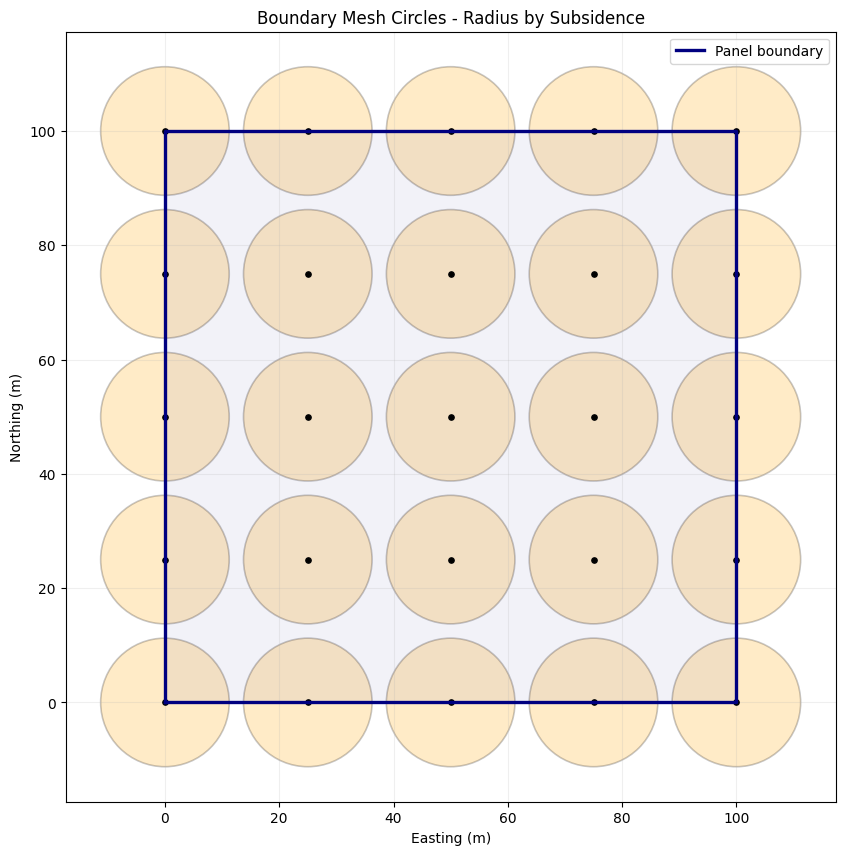

In [15]:
panel_points = [(0.0, 0.0), (100.0, 0.0), (100.0, 100.0), (0.0, 100.0)]

report = create_report(
    panel_points=panel_points,
    thickness=2.5,
    depth_of_cover=300.0,
    extraction_ratio=1.0,
    subsidence_factor=0.5,
    new_ratio=1.4,
    angle_of_draw_deg=35.0,
    mesh_spacing=25.0,
)

print(format_report(report))
fig = build_plotly_map(report)
if fig is not None:
    fig.show()

plot_circle_mesh_view(report)